In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json

In [ ]:
config = {
            "optimizer" : {
                "path" : "sacri-agi-tank-elements-withexos",
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980, # Vulbis
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        # 14093, # Botas kuko
                        # 18718, # Escudo kuko
                        # 14092, # Anillo kuko
                        # 8993, # Espada maldita
                        7754, # Dofus ocre
                        # 13641, 13642, # Noai con exos
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 5,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        26: {
                            "target": 100,  # Lock
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 6000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 30, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 30, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 30, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 30, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 30, # %res strength
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },

                "level_offset": 10,  # Level offset for items
                "objective": "elements",  # Objective to optimize, can be "weapon" or "elements"
                "normalize_by_apcost" : False # If False, only care about absolute damage regardless of AP cost
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1 # Exo MP
                    },  
                "distributed_points": {
                    9: 995,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    # 45  # Strength
                ],
                "melee" : True,
                "ranged" : False
            }
        }

# Insert a list of initial user guesses, e.g., current set to use in optimization
initial_options = [
]
config["optimizer"]["initial_options"] = initial_options

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2709
Total item sets: 148
Total pools:
   16 with sizes [69, 81, 71, 71, 62, 81, 40, 88, 69, 411, 1, 325, 325, 325, 325, 325]
Total combinations: 10^31.71


In [5]:
solutions = opt.optimize(islands = 16,
                          max_workers = 4)

/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with 

## Analysis

In [6]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 84


In [7]:
analyzer.report_extended_results()

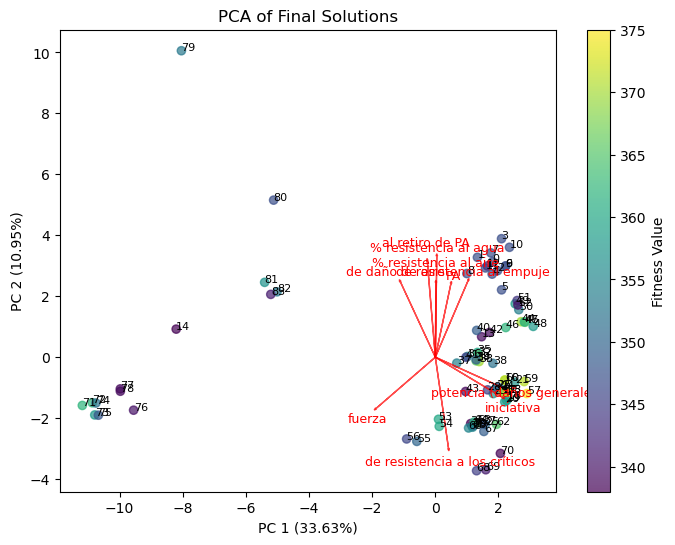

In [8]:
analyzer.plot_pca()

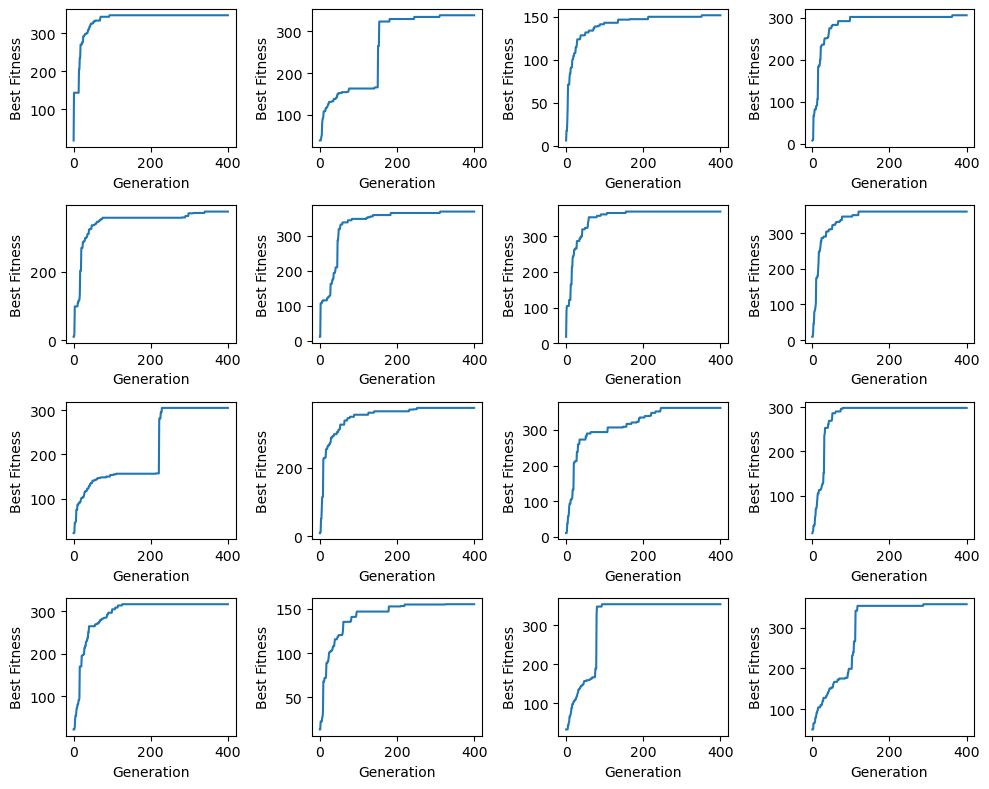

In [9]:
analyzer.report_generations()

In [10]:
assert False

AssertionError: 

In [ ]:
# Current
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 18043 # Dofus
                 ],
                 opt)
chr.fitness, chr.get_final_damage("weapon")

In [ ]:
Items.loc[chr.chromosome]

In [ ]:
chr.totals_summary()

In [ ]:
Items[Items["name"].str.contains("abisal",case=False)]

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary()

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)